In [108]:
# -*- coding: utf-8 -*-
#  Copyright 2025 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by:    Laura Murgatroyd (UKRI-STFC)

# Introduction to Golden Ratio Scanning
This notebook introduces golden ratio scanning and why it can be a useful acquisition protocol, especially if experiments are at risk of being interrupted.
It also introduces weighted FBP and how it can be used to reconstruct data like the golden ratio data which does not have equal angular spacing between projections.


In [109]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

from cil.utilities.display import show2D, show1D
from cil.utilities.jupyter import islicer, link_islicer
from cil.plugins.astra import FBP as FBP_ASTRA
from cil.processors import Slicer 
from cil.framework import DataContainer

from data_io.io import read_mantid_imaging_data
from recon.weighted_fbp import run_weighted_fbp_parallel
from utils.lego_man import get_masks
from utils.lego_man import calculate_metrics, make_bar_plots

## Data

This notebook uses a dataset of a lego man imaged at IMAT. The lego man is inside a lead container.

The same sample was imaged twice:

1. Equidistant protocol: with angles incrementally increased by the same amount and rotated through a total of 360 degrees.

2. Golden ratio protocol: angles increased by an amount determined by the golden ratio, across 180 degrees. Projections were acquired until they ran out of experiment time so we have more projections for this dataset.

You will need to download the dataset `preprocessed_data.zip` from https://zenodo.org/records/17814677:

    https://zenodo.org/records/17814677/files/preprocessed_data.zip

Please update the filepath below:

In [ ]:
base_path = "preprocessed_data/"

Here we load in data which has already been preprocessed in Mantid Imaging:

In [111]:
# pixel size in cm, which is listed on the zenodo page:
pixel_size = 100*10**-4

gr_full = read_mantid_imaging_data(os.path.join(base_path, "Golden_Ratio"), pixel_size=pixel_size)
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=pixel_size)

# exclude the duplicate projection from the full equidistant data:
equi_full = Slicer(roi={'angle':(0,-1)})(equi_full)

We can take a look at the projections and reconstruct the scan acquired with the equidistant protocol:

In [112]:
islicer(equi_full, title='Projections', origin='upper-left', direction='angle')

In [113]:
equi_full.reorder('astra')
equi_full_recon = FBP_ASTRA(equi_full.geometry.get_ImageGeometry(), equi_full.geometry)(equi_full)

islicer(equi_full_recon, title='Full Equidistant Scan Reconstruction')

In this notebook we'll focus on a single slice of the data. The data has some artifacts due to neutron starvation, which will be discussed in another notebook. We choose to focus on a slice without these artifacts as they aren't relevant to the golden angle study.

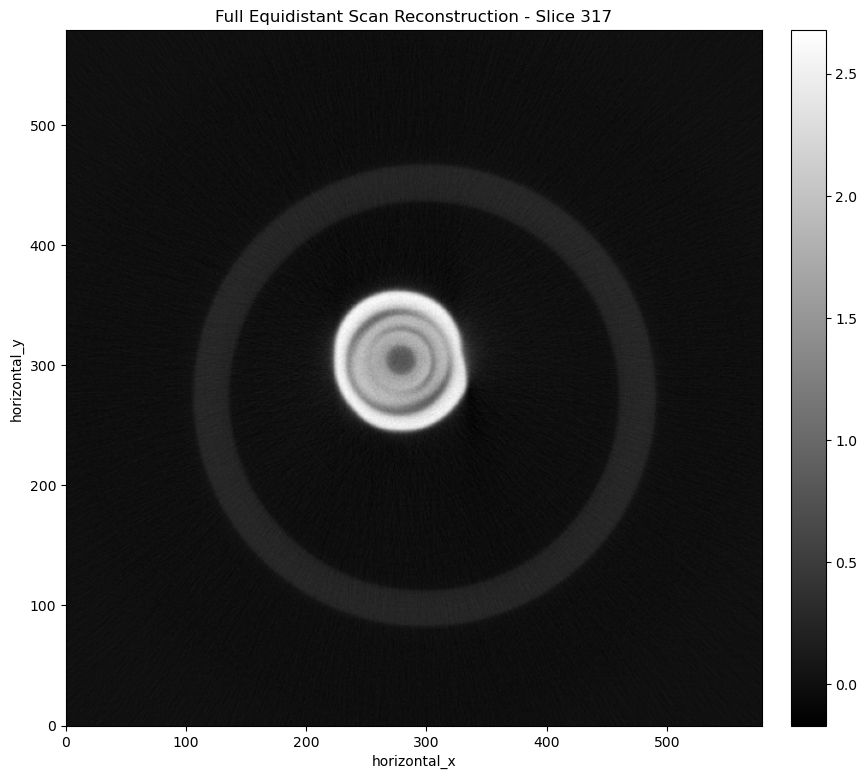

In [114]:
recon_full_equi_slice = equi_full_recon.get_slice(vertical=317)
show2D(recon_full_equi_slice, title='Full Equidistant Scan Reconstruction - Slice 317')

Here we create some masks of different regions of interest (ROIs) in the data:

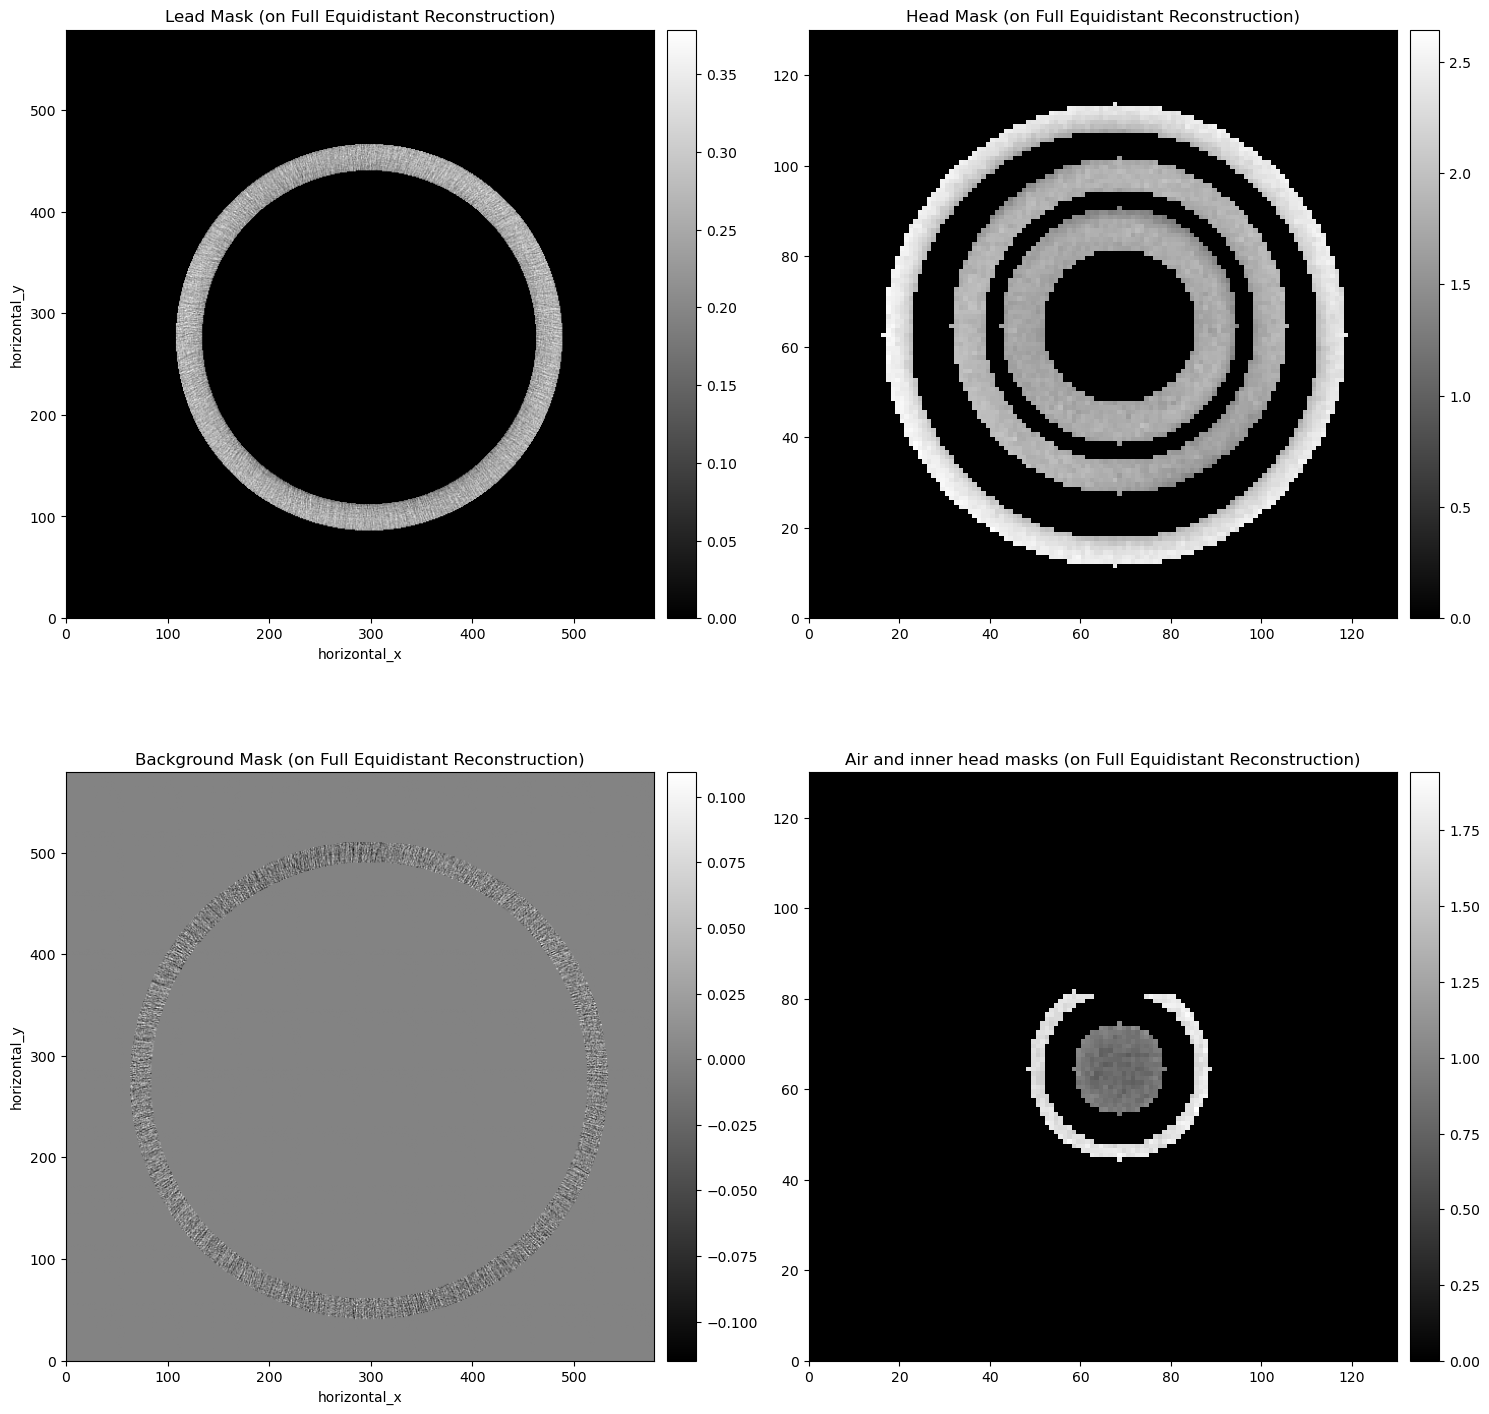

In [115]:
masks = get_masks()
lead_mask = masks['lead_mask']
total_head_mask = masks['total_head_mask']
air_in_head_mask = masks['air_in_head_mask']
inner_head_mask = masks['inner_head_mask']
background_mask = masks['background_mask']

masked_recon_lead = recon_full_equi_slice * lead_mask
masked_recon_head = recon_full_equi_slice * total_head_mask
masked_recon_air_in_head = recon_full_equi_slice * air_in_head_mask + recon_full_equi_slice * inner_head_mask
masked_recon_bkg = recon_full_equi_slice * background_mask

show2D([masked_recon_lead, masked_recon_head.array[240:370, 210:340], masked_recon_bkg, masked_recon_air_in_head.array[240:370, 210:340]],
       title=['Lead Mask (on Full Equidistant Reconstruction)','Head Mask (on Full Equidistant Reconstruction)', 'Background Mask (on Full Equidistant Reconstruction)', 'Air and inner head masks (on Full Equidistant Reconstruction)'],
       cmap='grey', num_cols=2)


Note: the background mask and lead mask have the same number of pixels because they will both be used in the contrast to noise metric later. Similar with the inner head mask and inner air mask shown in the 4th image.

## Golden Ratio Scanning

Spacing projection angles using the golden ratio ensures that we get a good coverage of angles, no matter what point we stop the experiment.

Sometimes the neutron beam goes down during an experiment at IMAT which means the data acquisition suddenly stops! Unfortunately the beam can be down for some time and it might mean a visiting scientist is unable to finish acquiring their data and has to work with what was collected so far.

The golden angle is defined as the smaller of the two angles created by sectioning a circle into two parts such that the ratio between the largest arc length and the circumference is equal to the ratio between the smallest and largest arc lengths - the golden ratio. This angle is ~137.51 degrees.

In the golden ratio scan acquired with the lego man, the angles were instead spaced across 180 instead of 360 degrees (half instead of full circle). In this case applying the golden ratio gives a large angle of 111.25 degrees and small angle of 68.75. In this scan the larger angle was used - 111.25 degrees.

Here we verify that the golden ratio scan has angles spaced by ~111.25 as we expect:


In [116]:
expected_gr_angles = np.mod(np.arange(0, gr_full.geometry.angles.size)*111.2461, 180)

print(np.allclose(expected_gr_angles, gr_full.geometry.angles, atol=1e-2))

True


Here we display the angles acquired using the equidistant incremental scan protocol and the golden ratio scan protocol. Initially showing the first 10 angles and then the full scan:

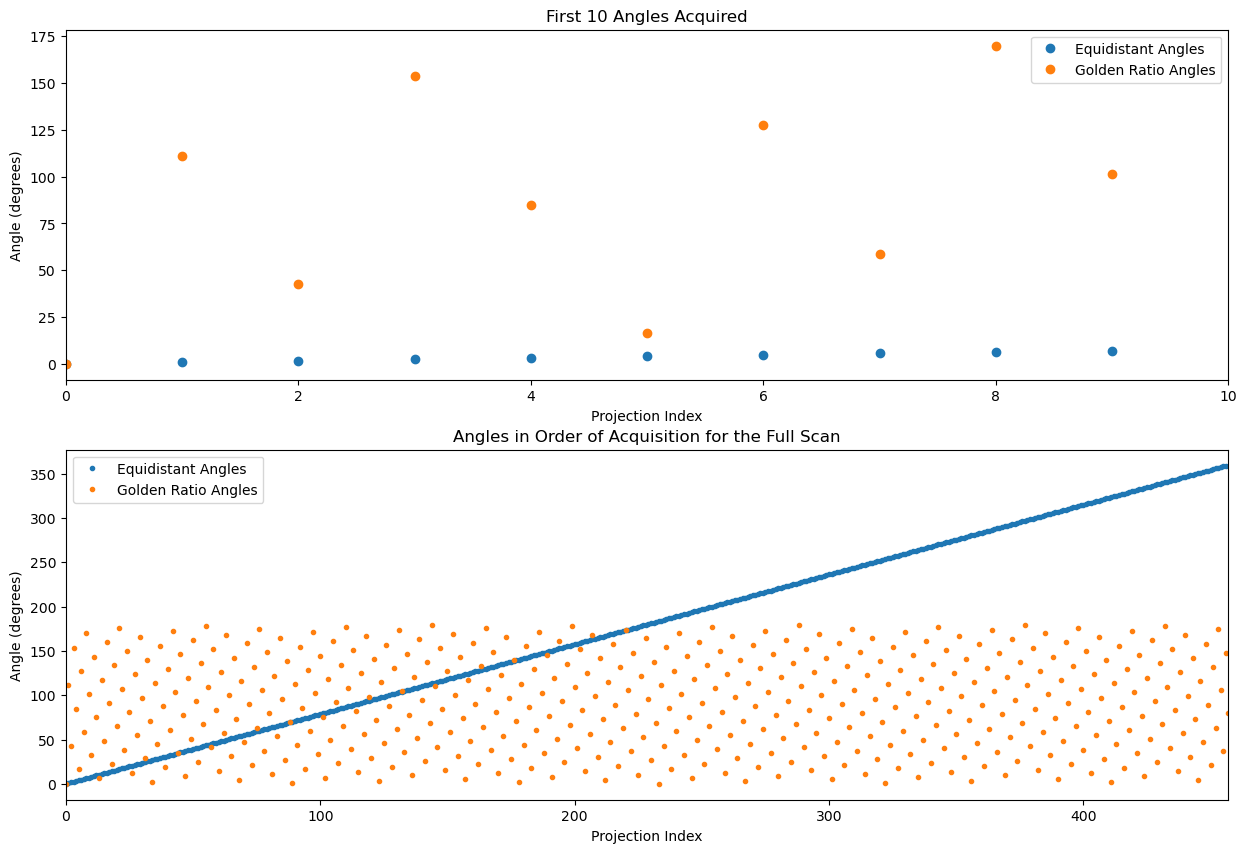

In [117]:
fig, axes = plt.subplots(2, 1, figsize=( 15,10))

# first 10 angles
axes[0].plot(equi_full.geometry.angles[0:10], label='Equidistant Angles', marker='o', linestyle='')
axes[0].plot(gr_full.geometry.angles[0:equi_full.geometry.angles.size+1][0:10],
             label='Golden Ratio Angles', marker='o', linestyle='')
axes[0].set_xlabel('Projection Index')
axes[0].set_ylabel('Angle (degrees)')
axes[0].set_xlim(0, 10)
axes[0].legend()
axes[0].set_title('First 10 Angles Acquired')

# full scan
axes[1].plot(equi_full.geometry.angles, label='Equidistant Angles', marker='.', linestyle='')
axes[1].plot(gr_full.geometry.angles[0:equi_full.geometry.angles.size+1],
             label='Golden Ratio Angles', marker='.', linestyle='')
axes[1].set_xlabel('Projection Index')
axes[1].set_ylabel('Angle (degrees)')
axes[1].set_xlim(0, equi_full.geometry.angles.size)
axes[1].legend()
axes[1].set_title('Angles in Order of Acquisition for the Full Scan')

plt.show()

We can also look at the angles distributed around a circle. At the end of the equidistant incremental scan, all angles are equidistantly distributed around the circle but with the golden ratio scan they aren't equidistant around a semicircle:

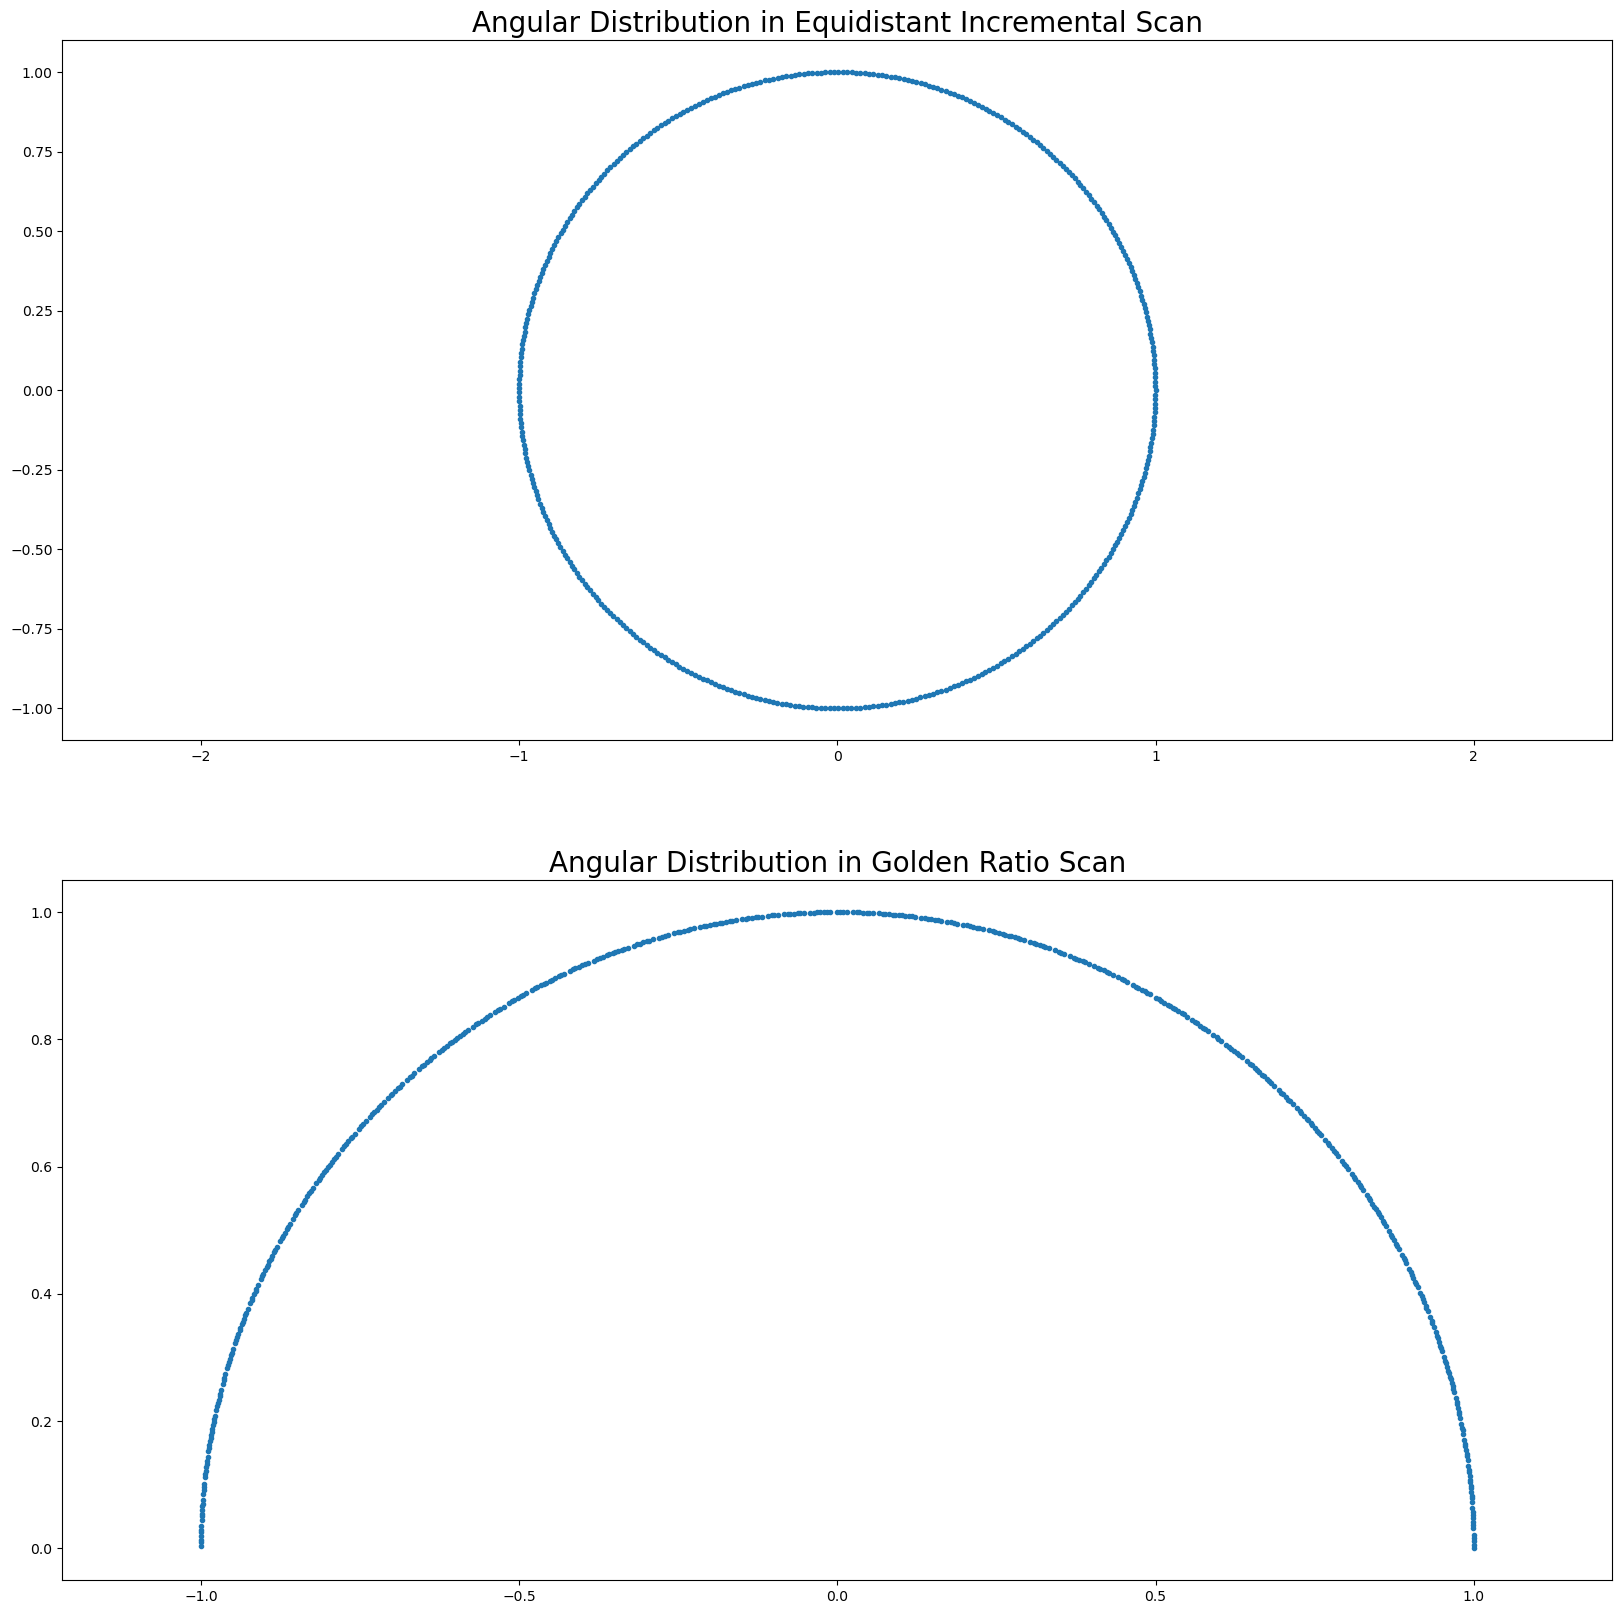

In [118]:
plt.figure(figsize=(20,20))
plt.subplot(2,1,1)
plt.plot(np.cos(equi_full.geometry.angles*np.pi/180), np.sin(equi_full.geometry.angles*np.pi/180),'.')
plt.axis('equal')
plt.title('Angular Distribution in Equidistant Incremental Scan',fontsize=20);

plt.subplot(2,1,2)
plt.plot(np.cos(gr_full.geometry.angles*np.pi/180), np.sin(gr_full.geometry.angles*np.pi/180),'.')
plt.axis('equal')
plt.title('Angular Distribution in Golden Ratio Scan',fontsize=20);

Or if we look at the angles in order of increasing angle instead of order of acquisition, and plot the difference between neighbouring angles, we see more clearly that for the golden angle data the angles are not equally spaced around 180 degrees:

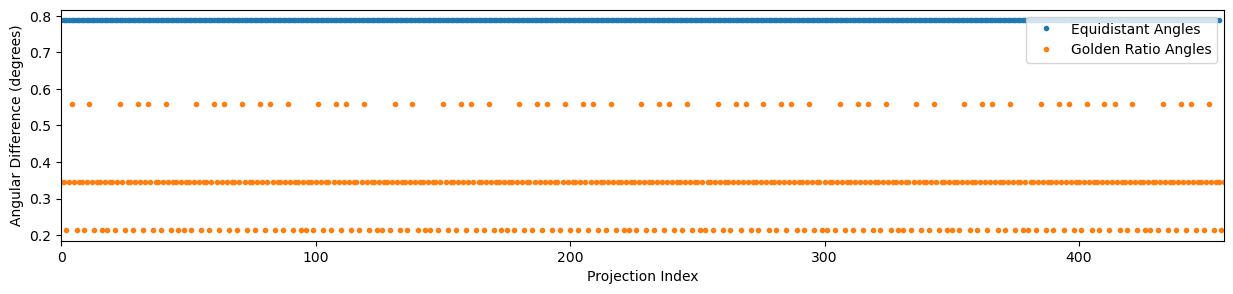

In [119]:
plt.figure(figsize=(15,3))
plt.plot(np.diff(equi_full.geometry.angles), label='Equidistant Angles', marker='.',linestyle='')
angles = np.diff(sorted(gr_full.geometry.angles))
plt.plot(angles, label='Golden Ratio Angles', marker='.',linestyle='')
plt.xlabel('Projection Index')
plt.ylabel('Angular Difference (degrees)')
plt.xlim(0, equi_full.geometry.angles.size)
plt.legend(loc='upper right')
plt.show()


## Reconstruction with Equidistant and Golden Ratio Scan Protocols

Here we reconstruct with FBP a slice of the lego dataset with both protocols. The slice is a cut through the lego man's head.

We vary the number of angles used in the reconstruction to show what data we would get if the experiment was interrupted part way through.

In [120]:

slice_num = 317
gr_full_slice = gr_full.get_slice(vertical=slice_num)
equi_full_slice = equi_full.get_slice(vertical=slice_num)
gr_full_slice.reorder('astra')
array_list_equi = []
array_list_gr = []
array_list_weighted_gr = []

angles_list = np.arange(10, 451,10)
angles_list = np.append(angles_list, 457)

for i in angles_list:

    reduced_angle_equi = Slicer(roi={'angle':(0,i)})(equi_full_slice)
    reduced_angle_gr = Slicer(roi={'angle':(0,i)})(gr_full_slice)
    
    recon_weighted = run_weighted_fbp_parallel(reduced_angle_gr)

    recon_equi = FBP_ASTRA(reduced_angle_equi.geometry.get_ImageGeometry(), reduced_angle_equi.geometry)(reduced_angle_equi )
    recon_gr = FBP_ASTRA(reduced_angle_gr.geometry.get_ImageGeometry(), reduced_angle_gr.geometry)(reduced_angle_gr )
    recon_slice_equi = recon_equi
    recon_slice_gr = recon_gr
    array_list_equi.append(recon_slice_equi.array)
    array_list_gr.append(recon_slice_gr.array)
    array_list_weighted_gr.append(recon_weighted.array)

In [ ]:
DC = DataContainer(np.stack(array_list_equi, axis=0), dimension_labels=tuple(['angle']) + recon_slice_equi.dimension_labels)
islicer_1 = islicer(DC, title=tuple(['Equidistant Scan, Number of angles: ' + str(p)  + ', index: ' for p in angles_list]), minmax=(-1,4)) 
DC = DataContainer(np.stack(array_list_gr, axis=0), dimension_labels=tuple(['angle']) + recon_slice_equi.dimension_labels)
islicer2 = islicer(DC, title=tuple(['Golden Ratio Scan, Number of angles: ' + str(p)  + ', index: ' for p in angles_list]), minmax=(-1,4))
DC = DataContainer(np.stack(array_list_weighted_gr, axis=0), dimension_labels=tuple(['angle']) + recon_slice_equi.dimension_labels)
islicer3 = islicer(DC, title=tuple(['Weighted Golden Ratio Scan, Number of angles: ' + str(p)  + ', index: ' for p in angles_list]), minmax=(-1,4)) 

Use the slider to see what the reconstruction looks like when we have different numbers of projections.
The reconstructed slice here is a slice through the legs of our lego man.

In [122]:
link_islicer(islicer_1, islicer2)

You can see that with even only 10 angles with the golden ratio scan we can see the rough shape of the lego man's head, whereas we can't at all with the incremental equidistant scan protocol.
If an experiment was interrupted early on, the data might be useful if we used the golden ratio acquisition, but not with the incremental equidistant acquisition protocol.

## Weighted FBP
We have also applied weighted FBP to the golden angle data. This takes into account the fact that the angles are not equally spaced, by weighting each projection by  a value proportional to the difference between the previous and next angle when the angles are ordered by increasing value.

Throughout this notebook, as well as comparing the equidistant and golden ratio scans, we'll be comparing the reconstructions with and without this weighting:

In [123]:
link_islicer(islicer2, islicer3)

How much the weighted reconstruction makes a difference varies as we change the number of angles.
When we have few angles, the reconstructions are both very streaky as we have missing information.
When we have lots of angles, the weighting makes less difference as the angular range is well sampled anyway.
In between is where we can see more of an impact. E.g. at 50 or 250 angles, the weighted reconstruction appears to have less streaks.

## Comparing Protocols based on Total Experiment Time

### Overhead with Golden Ratio Scanning

Above, we compared the number of angles acquired with golden ratio scanning and equidistant scanning. However, the time taken to rotate through the small angle used for each step in the equidistant scan is not the same as the time taken to rotate through the larger, golden ratio angle.

In the lego man experiment it was found that the time taken to acquire each projection was on average:

52.78s for the golden ratio scan protocol

35s for the equidistant incremental scan protocol

However it may be the case that the overhead for golden angle scanning reduces in future (or may even have reduced since this data was acquired!) due to improved technology or scripting in the future.

### What if both protocols are interupted after 1:07 hours?

1:07h was chosen as this was the time taken to acquire 25% of the equidistant incremental scan.

In this time, the number of projections acquired would be:

75 - with the golden ratio protocol

114 - with the equidistant incremental protocol

Here we compare the results with the full equidistant data

In [124]:
sliced_incr = Slicer(roi={'angle':(0,114)})(equi_full_slice)
sliced_gr = Slicer(roi={'angle':(0,75)})(gr_full_slice)
sliced_gr.reorder('astra')
sliced_incr.reorder('astra')

recon_reduced_equi = FBP_ASTRA(sliced_incr.geometry.get_ImageGeometry(), sliced_incr.geometry)(sliced_incr)
recon_reduced_gr = FBP_ASTRA(sliced_gr.geometry.get_ImageGeometry(), sliced_gr.geometry)(sliced_gr)
recon_reduced_gr_weighted = run_weighted_fbp_parallel(sliced_gr)

data_list = [recon_full_equi_slice, recon_reduced_equi, recon_reduced_gr, recon_reduced_gr_weighted]
data_labels = ['Equidistant [proj=457, time=4:28h]', 'Equidistant [proj=114, time=1:07h]', 'Golden Ratio [proj=75, time=1:07h]', 'Weighted Golden Ratio [proj=75, time=1:07h]']


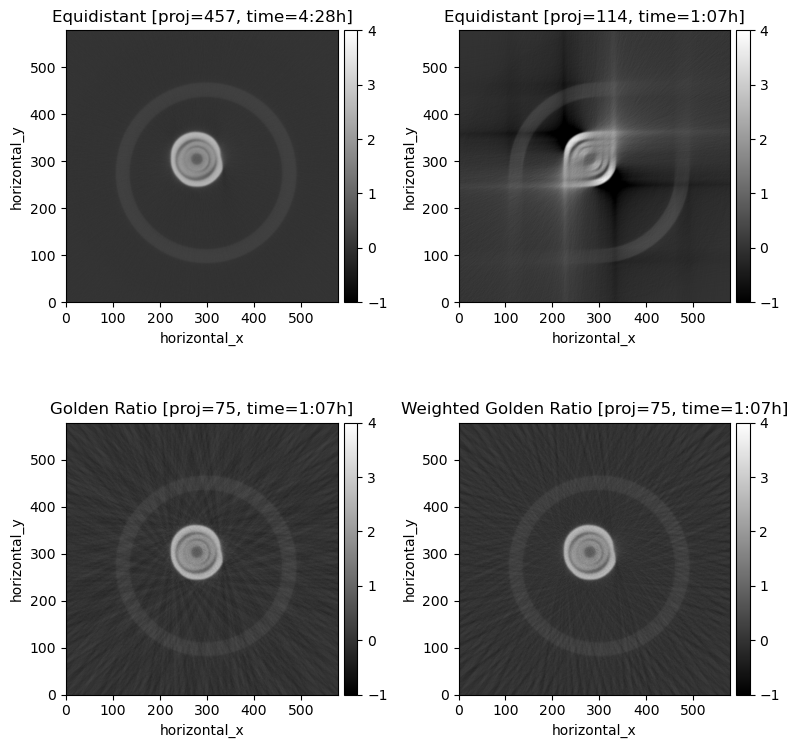

In [125]:
show2D(data_list, title=data_labels, fix_range=(-1,4), num_cols=2, size=(8,8))

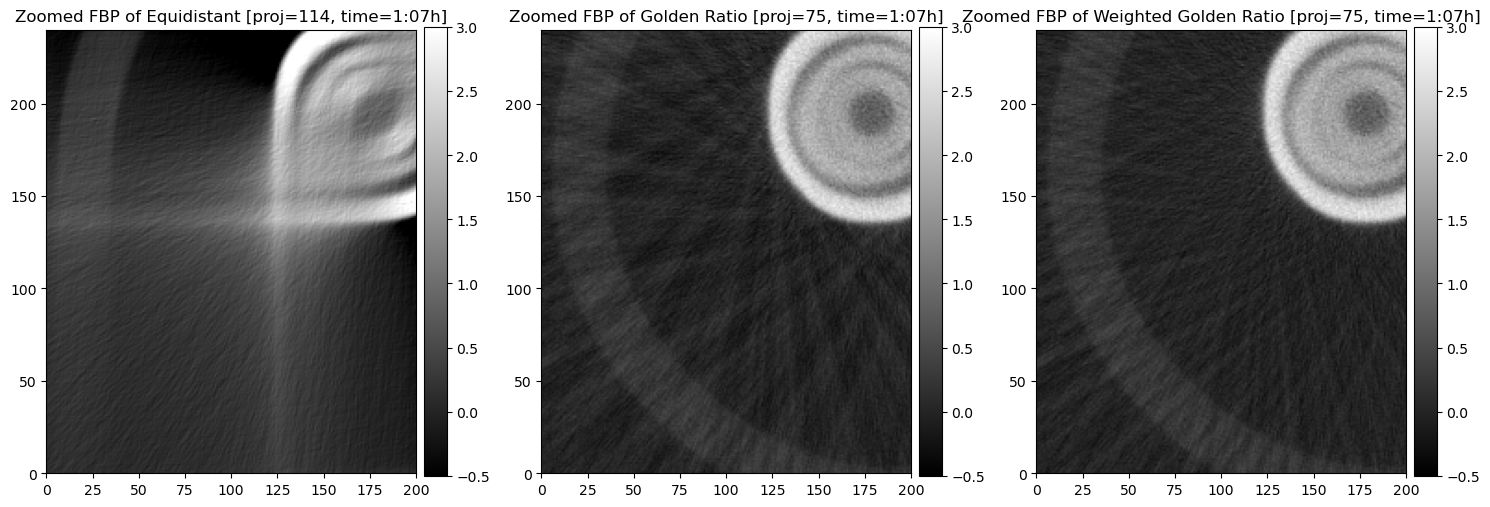

In [126]:
show2D([d.array[110:350, 100:300] for d in data_list[1:]], title=[ "Zoomed FBP of " + x for x in data_labels[1:]], fix_range=(-0.5, 3), num_cols=3)

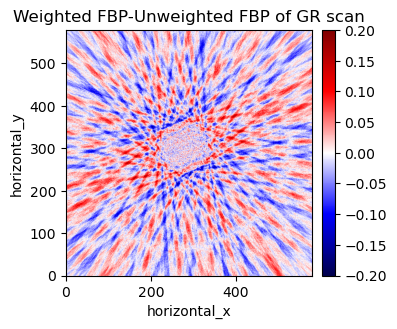

In [127]:
show2D([recon_reduced_gr_weighted- recon_reduced_gr], cmap='seismic', size=(6,6), fix_range=(-0.2,0.2), title="Weighted FBP-Unweighted FBP of GR scan")

Here we look at slice horizontal_y=270 which cuts through the outer lead plus two layers of the lego man's head

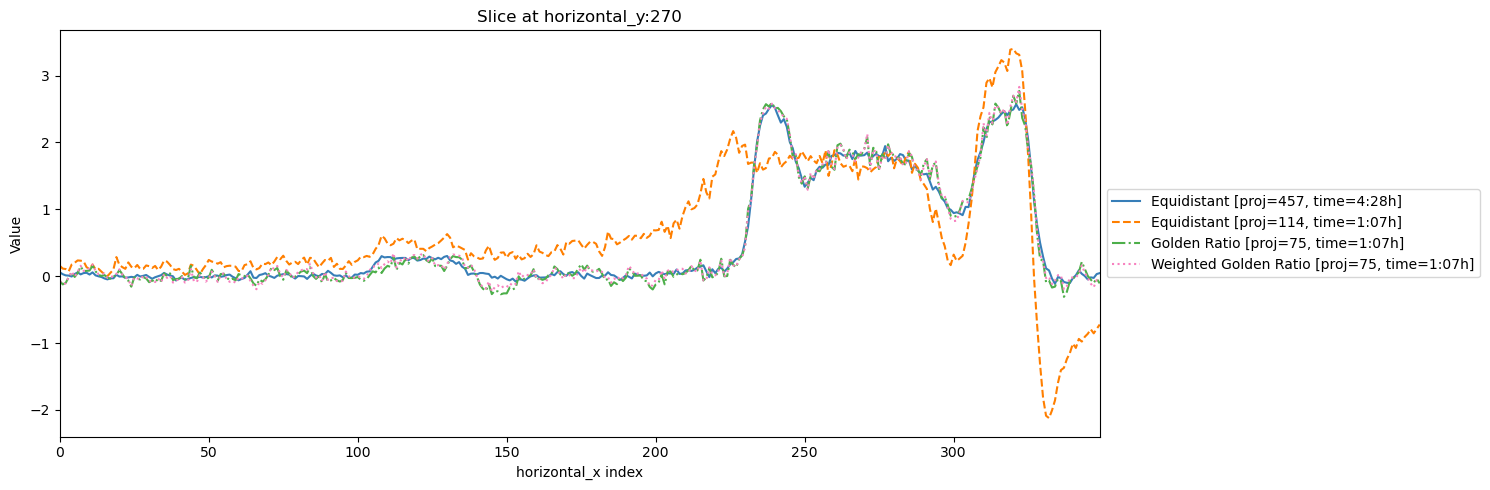

In [128]:
sl = Slicer(roi={'horizontal_x':(0,350)})
show1D([sl(x) for x in data_list], slice_list=[('horizontal_y',270)], dataset_labels=data_labels, size=(15,5))

We see similar pixel values between the golden ratio reconstructions and the full equidistant reconstruction.

Beginning around 230 on horizontal_x is the start of the lego man's head. We can see in the equidistant scan the values increase earlier than this, showing that the FBP is putting material in this region, whereas this is not happening in the golden ratio acquisition.

Throughout the line profile we see that the reduced golden ratio scan does not stray far from the line profile for the full equidistant scan.

Here we will apply metrics: L2Norm Error, Signal to Noise Ratio (SNR) and Contrast to Noise Ratio 

The L2Norm Error is measured between each reconstruction and the full equidistant reconstruction. Lowest value is best.

The SNR looks at the signal compared to noise in ROIs of the lead and a lego head. Highest value is best.

The CNR looks at the contrast to noise ratio in the lead compared to the background, and the inner layer of the lego man head compared to the air inside the lego man head.

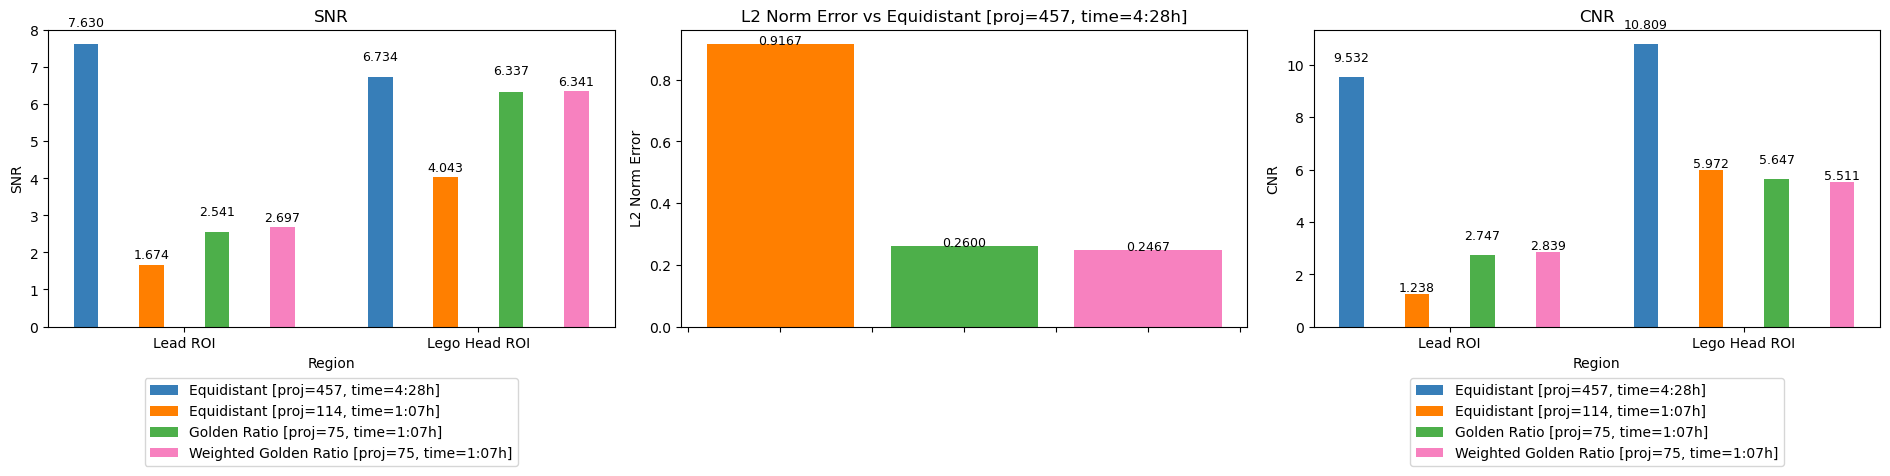

In [129]:
l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner = calculate_metrics(recon_full_equi_slice, data_list[1:])
make_bar_plots(l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner, data_labels)

The signal to noise ratio in both of the ROIs is highest in the weighted reconstruction of the golden ratio scan, showing both that the golden ratio scan is advantageous over the equidistant scan in the reduced case, and that the weighted FBP provides an improved reconstruction. We see the same pattern with the CNR for the lead but not for the head, although the difference is small and we don't have a lot of statistics in that ROI.

As expected, we see a much larger L2Norm Error for the Equidistant Incremental protocol, and a reduction in error when using weighted FBP.

The head ROI has a much higher SNR in the reduced scans than the lead ROI. This could be because its closer to the centre of the scan, or due to the fact that the number of pixels in the head ROI is much less than the lead ROI, so they aren't really fairly comparable.

## What if the Experiment All Goes To Plan?

So far we've discussed the worst case scenarios of the neutron beam going down mid experiment, but what if everything goes to plan and we can acquire all of the projections we planned?

Would a 'full' golden angle dataset look just as good as a 'full' incremental scan?

### If we had the time taken to acquire the number of projections for the incremental scan: 4h28

In the full incremental scan we acquired 457 projections and it took 4h28mins

In 4h28 min we acquired 303 projections with the golden ratio protocol.

Let's compare the reconstructions

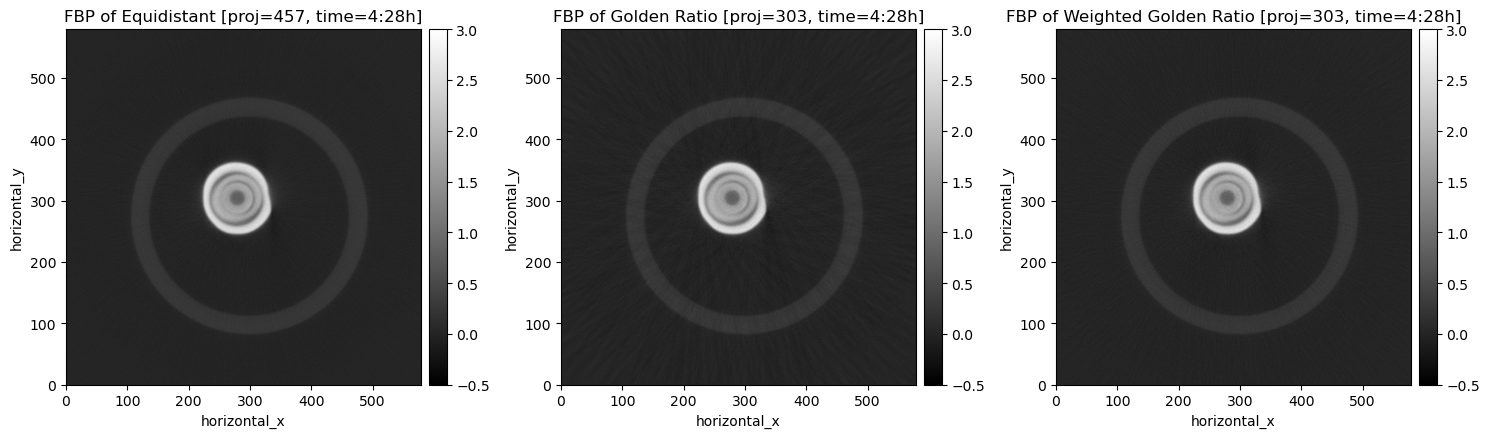

In [130]:
sliced_gr_2 = Slicer(roi={'angle':(0,303)})(gr_full_slice)
sliced_gr_2.reorder('astra')
recon_reduced_gr_2 = FBP_ASTRA(sliced_gr_2.geometry.get_ImageGeometry(), sliced_gr_2.geometry)(sliced_gr_2)
recon_reduced_gr_2_weighted = run_weighted_fbp_parallel(sliced_gr_2)
data_labels2=['Equidistant [proj=457, time=4:28h]', 'Golden Ratio [proj=303, time=4:28h]', 'Weighted Golden Ratio [proj=303, time=4:28h]']
data_list2 = [recon_full_equi_slice, recon_reduced_gr_2, recon_reduced_gr_2_weighted]
show2D(data_list2,
       title=[ "FBP of " + x for x in data_labels2], num_cols=3, fix_range=(-0.5, 3))


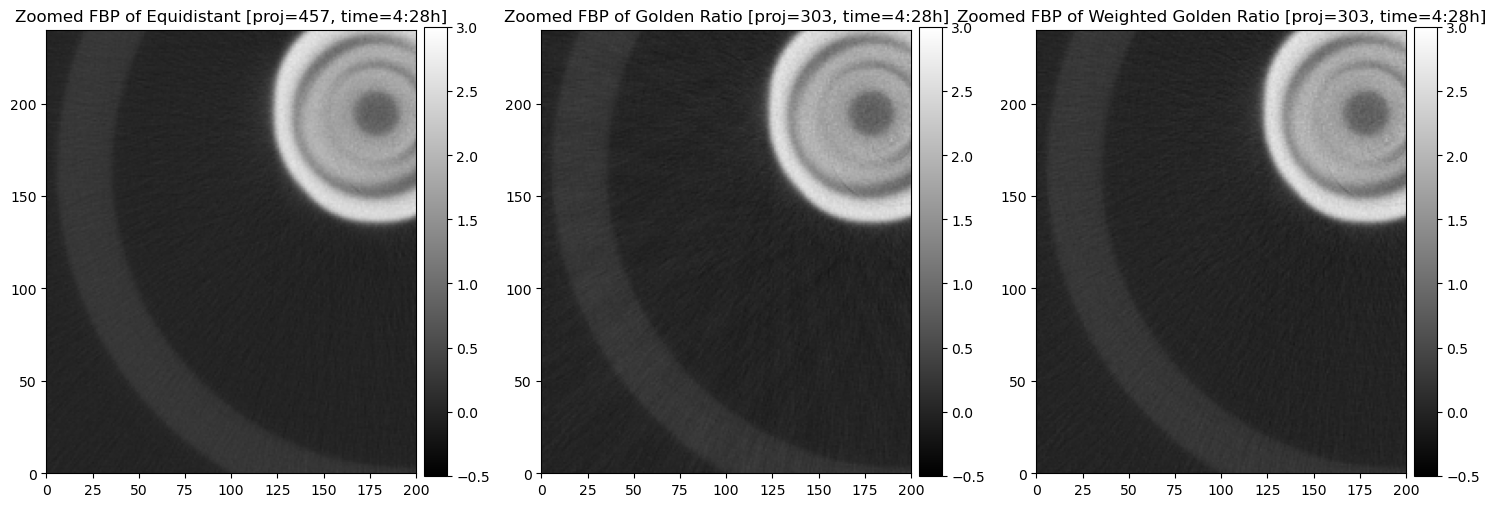

In [131]:
show2D([d.array[110:350, 100:300] for d in data_list2], title=[ "Zoomed FBP of " + x for x in data_labels2], fix_range=(-0.5, 3), num_cols=3)

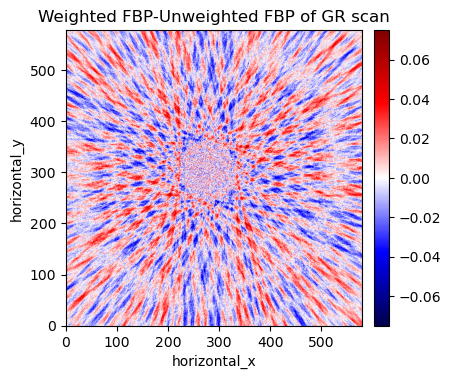

In [132]:
show2D([recon_reduced_gr_2_weighted- recon_reduced_gr_2], cmap='seismic', size=(7,7), title="Weighted FBP-Unweighted FBP of GR scan", fix_range=(-0.075, 0.075))

We see more streak artifacts in the golden ratio scan. This is because we have less projections in the same amount of time.

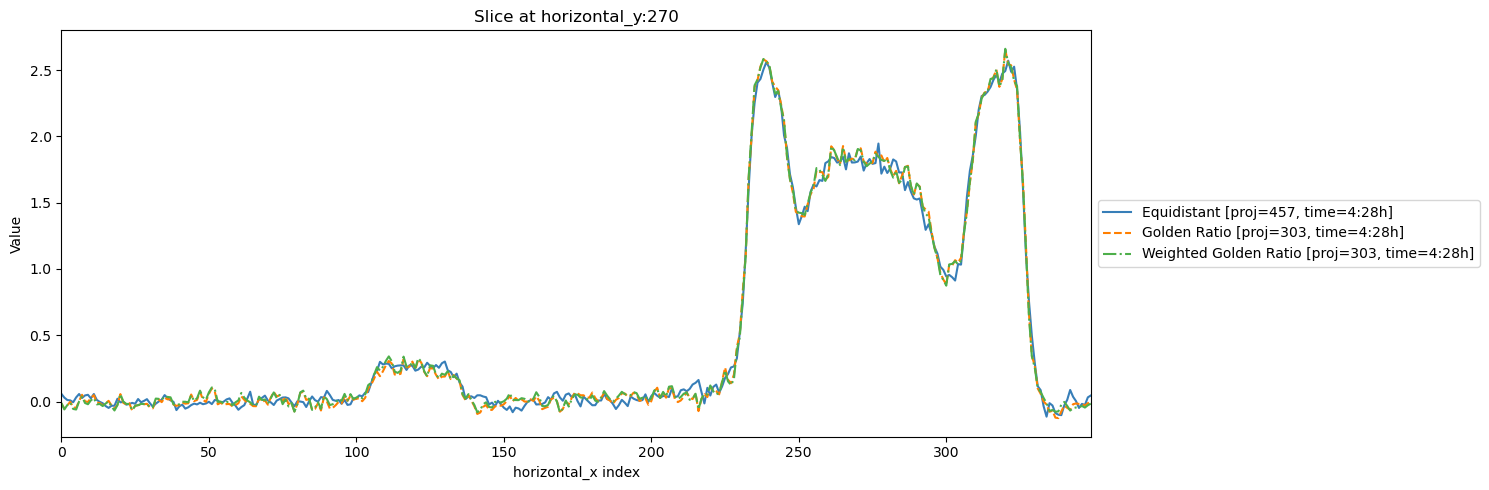

In [133]:
show1D([sl(recon_full_equi_slice), sl(recon_reduced_gr_2), sl(recon_reduced_gr_2_weighted)], slice_list=[('horizontal_y',270)], dataset_labels=data_labels2, size=(15,5))

The pixel values are very similar between the scans

In [134]:
l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner = calculate_metrics(recon_full_equi_slice, [recon_reduced_gr_2, recon_reduced_gr_2_weighted])

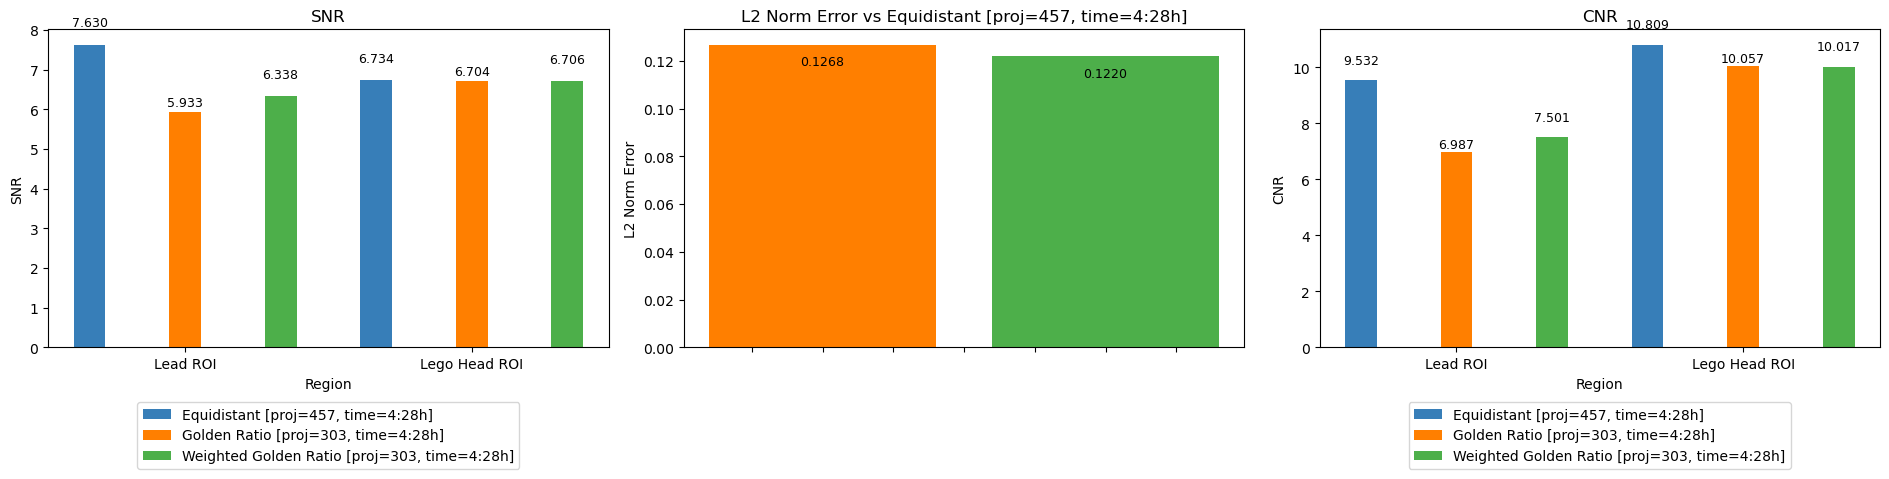

In [135]:

make_bar_plots(l2n_values, snr_lead, snr_leg, cnr_values,cnr_values_inner, data_labels2)

The metrics again show overall that for the golden ratio scan we have an improved reconstruction with weighted FBP.

The SNR in the lego in the golden ratio scans is closer to that for the equidistant scan. One possibility for this difference is that the lead is further out in the image. A non-consistent angular sampling impacts features further out in the image, more than ones in the centre.

### If we acquired 457 projections with both protocols

To acquire 457 projections:
- It takes 4h28 with the incremental protocol
- But 6h43 with the golden ratio protocol

This is ~50% longer.

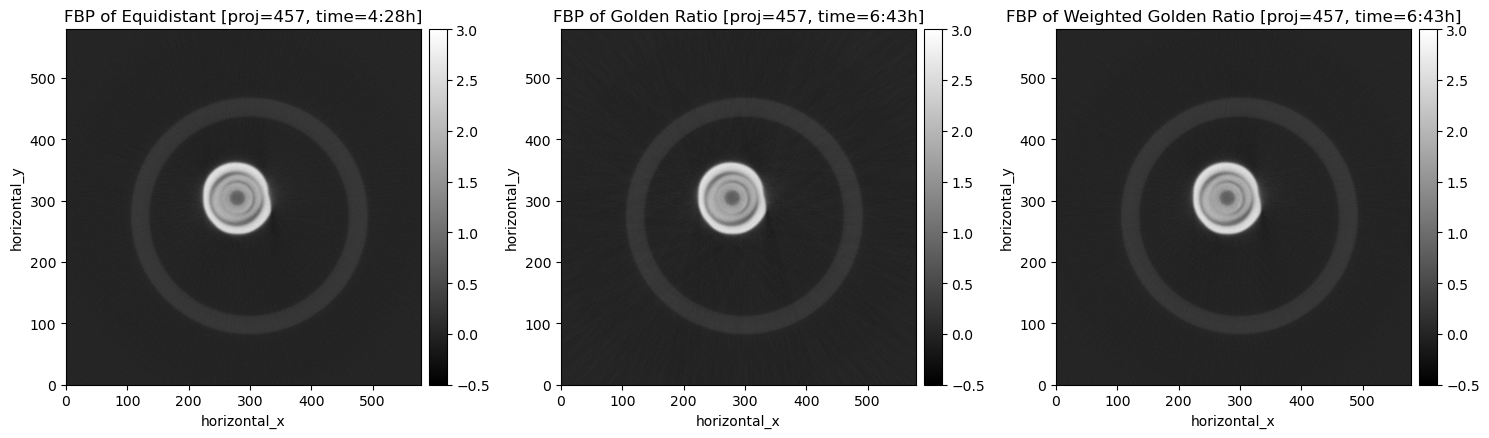

In [136]:
sliced_gr_3 = Slicer(roi={'angle':(0,457)})(gr_full_slice)
sliced_gr_3.reorder('astra')
recon_reduced_gr_3 = FBP_ASTRA(sliced_gr_3.geometry.get_ImageGeometry(), sliced_gr_3.geometry)(sliced_gr_3)
weighted_recon_reduced_gr_3 = run_weighted_fbp_parallel(sliced_gr_3)

data_list3 = [recon_full_equi_slice, recon_reduced_gr_3, weighted_recon_reduced_gr_3]

data_labels3 = ['Equidistant [proj=457, time=4:28h]', 'Golden Ratio [proj=457, time=6:43h]', 'Weighted Golden Ratio [proj=457, time=6:43h]']
show2D(data_list3, title=[ "FBP of " + x for x in data_labels3],  fix_range=(-0.5, 3), num_cols=3)

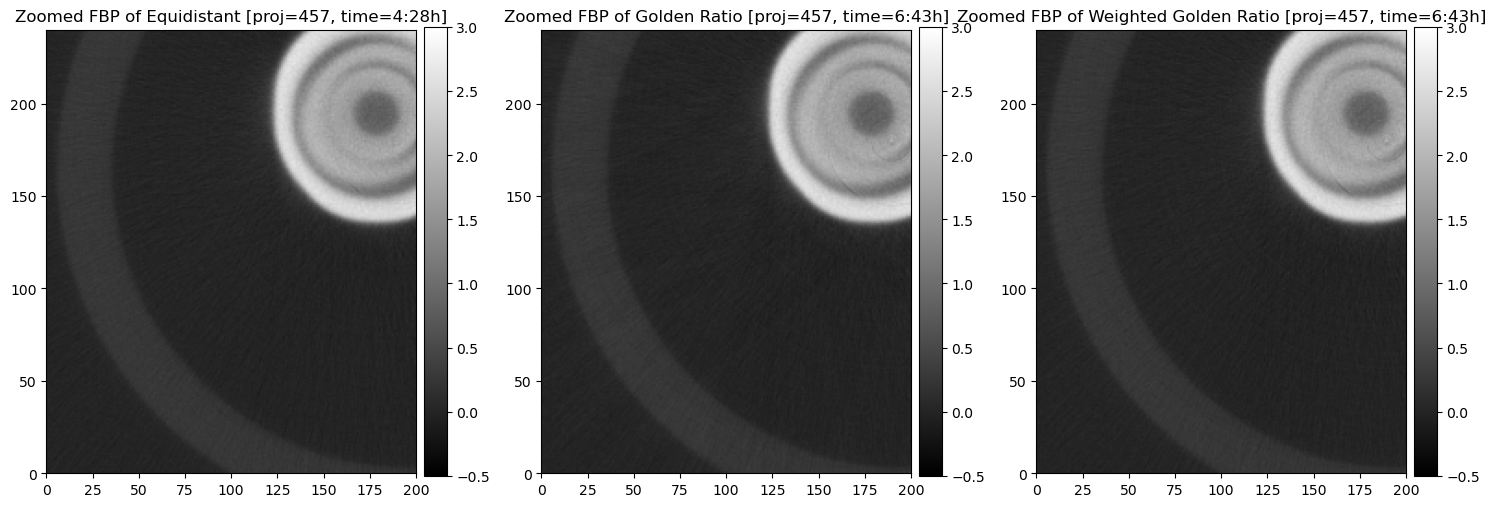

In [137]:
show2D([d.array[110:350, 100:300] for d in data_list3], title=[ "Zoomed FBP of " + x for x in data_labels3], fix_range=(-0.5, 3), num_cols=3)

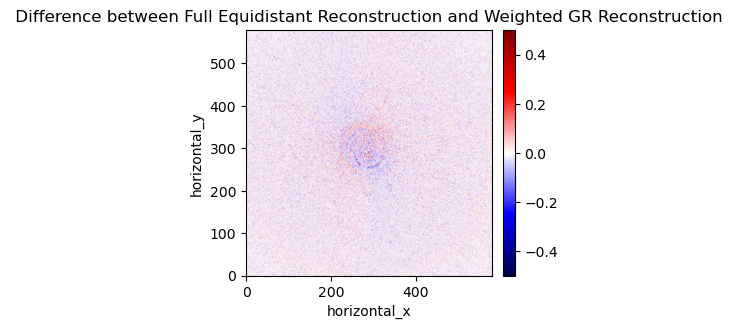

In [138]:
show2D([recon_full_equi_slice - weighted_recon_reduced_gr_3], cmap='seismic', fix_range=(-0.5, 0.5), title=[' Difference between Full Equidistant Reconstruction and Weighted GR Reconstruction '], size=(6,6))

There isn't a noticeable difference in the number of streak artifacts in one scan compared to the other. The main difference is we see more pronounced ring artifacts in the golden ratio scan. This might be contributed to by the fact that the golden ratio scan was over 180 degrees whereas the equidistant was over 360 degrees. 

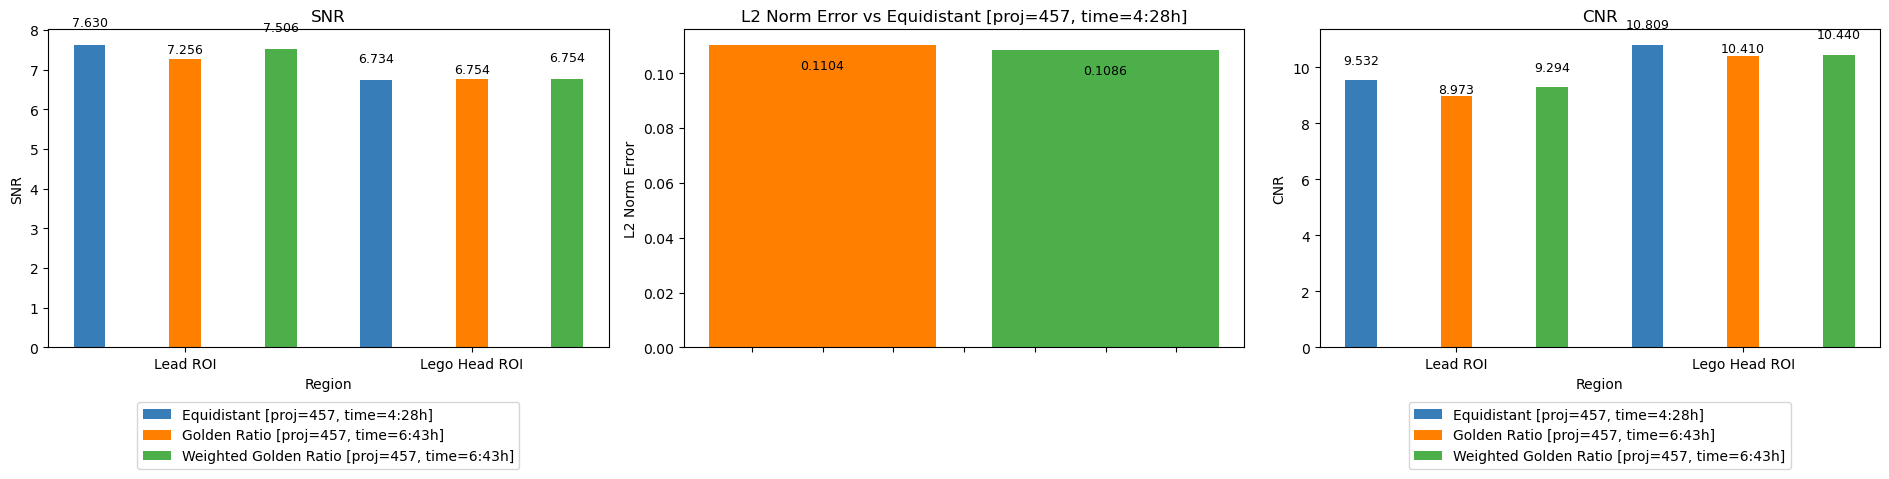

In [139]:
l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner = calculate_metrics(data_list3[0], data_list3[1:])
make_bar_plots(l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner, data_labels3)

We see a similar trend in metrics. Plus the results with the weighted FBP golden ratio scan are very close to that with the equidistant protocol, showing that with sufficient angles, the two acquisition protocols are very comparable.

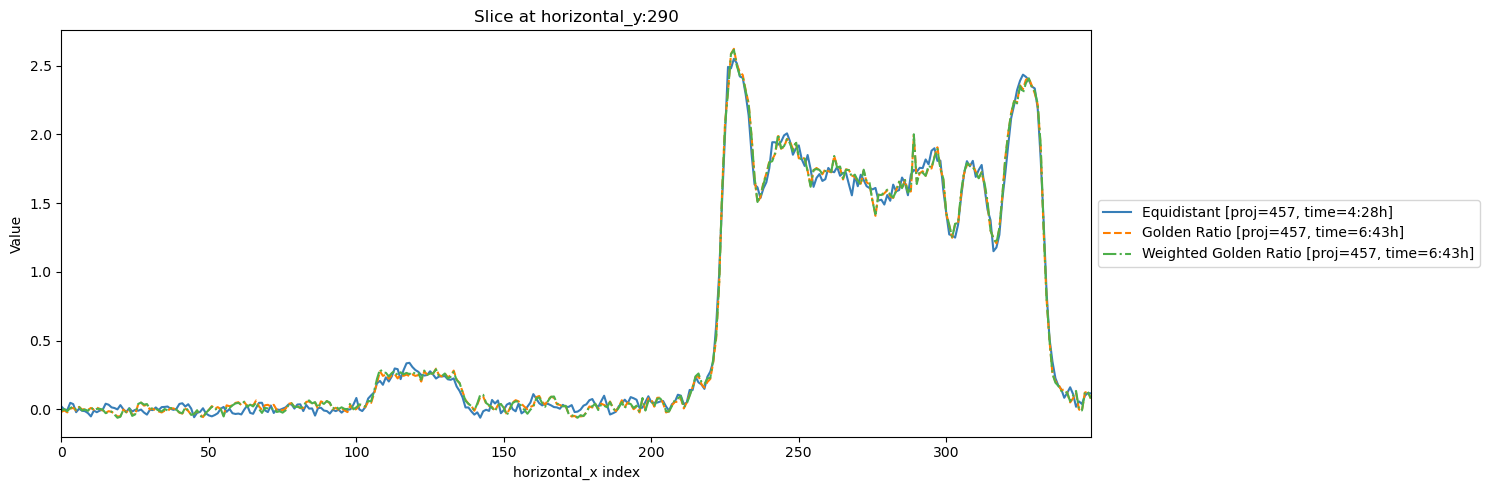

In [140]:
show1D([sl(x) for x in data_list3], slice_list=[('horizontal_y',290)], dataset_labels=data_labels3, size=(15,5))

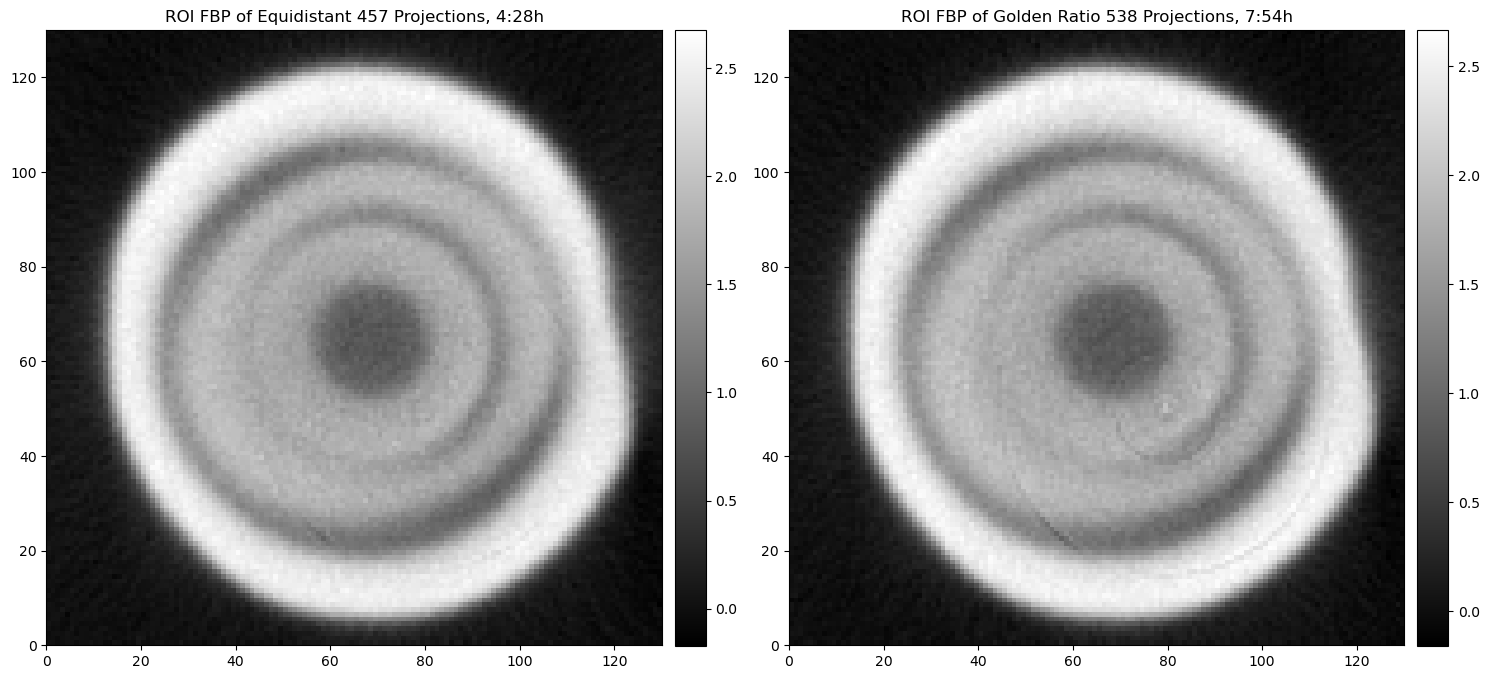

In [141]:
show2D([recon_full_equi_slice.array[240:370, 210:340], weighted_recon_reduced_gr_3.array[240:370, 210:340]],
       title=[ "ROI FBP of Equidistant 457 Projections, 4:28h", "ROI FBP of Golden Ratio 538 Projections, 7:54h"])

There isn't a noticeable difference in the number of streak artifacts in one scan compared to the other. The main difference is we see more pronounced ring artifacts in the golden ratio scan. This might be contributed to by the fact that the golden ratio scan was over 180 degrees whereas the equidistant was over 360 degrees. 

## Conclusion

This notebook has demonstrated that golden ratio scanning can be used to obtain useful data for this dataset even when the experiment time is significantly reduced (e.g. by 75%!), especially if weighted FBP is applied.

It is also shown that with full experiment time, the golden ratio acquisition protocol produces a reconstruction of similar quality to the equidistant protocol.

A wider study, of further real and simulated datasets which have features across the entire field of view, is required to establish a generic rule for how much the number of projections can be reduced using golden angle scanning.